<a href="https://colab.research.google.com/github/joseremedios-max/Avaliacao_anemia_offline/blob/main/sangue_virtual_ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**PyTorch** Dataset

In [ ]:
from google.colab import files
import os

print("1. Clique no botão abaixo e selecione o arquivo do dataset que você baixou no seu computador:\n")
uploaded = files.upload()

# Pega o nome do arquivo que você acabou de enviar
nome_arquivo = list(uploaded.keys())[0]
print(f"\nArquivo '{nome_arquivo}' recebido na nuvem. Iniciando extração cirúrgica...")

# Cria a pasta diretriz do nosso projeto
diretorio_destino = '/content/cp_anemic_data'
os.makedirs(diretorio_destino, exist_ok=True)

# Descompacta automaticamente dependendo do formato
if nome_arquivo.endswith('.zip'):
    !unzip -q -o "{nome_arquivo}" -d "{diretorio_destino}"
    print("Extração ZIP concluída!")
elif nome_arquivo.endswith('.rar'):
    !unrar x -Y "{nome_arquivo}" "{diretorio_destino}/"
    print("Extração RAR concluída!")
else:
    print("Formato não reconhecido. Por favor, envie o arquivo original .zip ou .rar")

# Validação Final do Pipeline
caminho_meta = os.path.join(diretorio_destino, 'metadata.csv')
caminho_img = os.path.join(diretorio_destino, 'images')

# OBS: Algumas extrações criam uma subpasta com o mesmo nome do arquivo.
# Esse bloco procura o metadata.csv caso ele tenha ficado escondido em uma subpasta.
if not os.path.exists(caminho_meta):
    for root, dirs, files_list in os.walk(diretorio_destino):
        if 'metadata.csv' in files_list:
            # Move tudo para o diretório raiz para padronizar nosso código anterior
            !mv "{root}/*" "{diretorio_destino}/"
            break

if os.path.exists(caminho_meta):
    print("\n🎉 SUCESSO ABSOLUTO! Os dados reais estão no Colab e prontos para a Inteligência Artificial.")
else:
    print("\n⚠️ Atenção: Os arquivos foram extraídos, mas o 'metadata.csv' não foi encontrado. Precisamos verificar a estrutura da pasta.")

1. Clique no botão abaixo e selecione o arquivo do dataset que você baixou no seu computador:



Saving Conjunto de dados CP-AnemiC.rar to Conjunto de dados CP-AnemiC.rar

Arquivo 'Conjunto de dados CP-AnemiC.rar' recebido na nuvem. Iniciando extração cirúrgica...

UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from Conjunto de dados CP-AnemiC.rar

Creating    /content/cp_anemic_data/Anemic                            OK
Extracting  /content/cp_anemic_data/Anemic/Image_001.png                   0%  OK 
Extracting  /content/cp_anemic_data/Anemic/Image_002.png                   0%  OK 
Extracting  /content/cp_anemic_data/Anemic/Image_005.png                   0%  OK 
Extracting  /content/cp_anemic_data/Anemic/Image_007.png                   1%  OK 
Extracting  /content/cp_anemic_data/Anemic/Image_009.png                   1%  OK 
Extracting  /content/cp_anemic_data/Anemic/Image_010.png                   1%  OK 
Extracting  /content/cp_anemic_data/Anemic/Image_013.png                   1%

**O** Processador em Lote Real

In [ ]:
'''import cv2
import numpy as np
import pandas as pd
import os
from glob import glob

# Diretórios base que o Colab acabou de extrair
DIRETORIO_BASE = '/content/cp_anemic_data'
pastas_classes = ['Anemic', 'Non-anemic']

def extrair_cores_conjuntiva(caminho_img):
    """ O exato mesmo pipeline cirúrgico que você validou no VS Code """
    img = cv2.imread(caminho_img)
    if img is None: return None

    # 1. Correção Gray World
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    r, g, b = cv2.split(img_rgb)
    r_mean, g_mean, b_mean = np.mean(r), np.mean(g), np.mean(b)
    gray_mean = (r_mean + g_mean + b_mean) / 3

    # Evitando divisão por zero
    r_scale = gray_mean / r_mean if r_mean > 0 else 1
    g_scale = gray_mean / g_mean if g_mean > 0 else 1
    b_scale = gray_mean / b_mean if b_mean > 0 else 1

    img_corrigida = cv2.merge([
        np.clip(r * r_scale, 0, 255).astype(np.uint8),
        np.clip(g * g_scale, 0, 255).astype(np.uint8),
        np.clip(b * b_scale, 0, 255).astype(np.uint8)
    ])

    # 2. Máscara Anti-Reflexo (Limiar cirúrgico > 245)
    gray_corr = cv2.cvtColor(img_corrigida, cv2.COLOR_RGB2GRAY)
    _, mask_brilho = cv2.threshold(gray_corr, 245, 255, cv2.THRESH_BINARY)
    mask_tecido_valido = cv2.bitwise_not(mask_brilho)

    # 3. Extração da Matriz de Cor Pura
    medias = cv2.mean(img_corrigida, mask=mask_tecido_valido)
    return medias[0], medias[1], medias[2] # R, G, B

# --- Loop de Processamento em Lote ---
dados = []
print("Iniciando a extração de dados reais. Isso pode levar alguns segundos...\n")

for classe in pastas_classes:
    caminho_pasta = os.path.join(DIRETORIO_BASE, classe)
    # Busca todas as imagens dentro da pasta (Anemic ou Non-anemic)
    imagens = glob(os.path.join(caminho_pasta, '*.*'))

    print(f"Processando pasta '{classe}' - Encontradas {len(imagens)} imagens.")

    # Atribui o Label matemático (1 para Anemia, 0 para Saudável)
    label = 1 if classe == 'Anemic' else 0

    for img_path in imagens:
        resultado = extrair_cores_conjuntiva(img_path)
        if resultado:
            r, g, b = resultado
            dados.append({
                'Arquivo': os.path.basename(img_path),
                'R_mean': r,
                'G_mean': g,
                'B_mean': b,
                'Classe': label,         # Dado para a IA (0 ou 1)
                'Diagnostico': classe    # Dado visual humano
            })

# Constrói o nosso "Excel" Virtual (DataFrame)
df_real = pd.DataFrame(dados)

print("\n🎉 Extração concluída com sucesso! Veja a matriz resultante das 5 primeiras fotos reais:")
display(df_real.head())
print(f"\nTotal de imagens clínicas processadas e purificadas: {len(df_real)}")

SyntaxError: incomplete input (2097961768.py, line 1)

**A** Correção Cirúrgica (Removendo o Gray World)

**Treinando** a IA de Classificação (O Diagnóstico)

In [ ]:
'''import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# 1. Isolando as Variáveis de Treino
# X = As Cores (O exame)
# y = A Classe (1 = Anêmico, 0 = Saudável)
X = df_real_corrigido[['R_mean', 'G_mean', 'B_mean']].values
y = df_real_corrigido['Classe'].values

# Dividindo os 710 pacientes: 80% para a IA estudar, 20% guardados para a Prova Final
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Configurando o Motor da GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Treinando IA usando Hardware: {device.type.upper()}\n")

# Convertendo dados para Tensores do PyTorch
X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.FloatTensor(y_train).view(-1, 1).to(device)
X_test_t = torch.FloatTensor(X_test).to(device)
y_test_t = torch.FloatTensor(y_test).view(-1, 1).to(device)

# 3. Construindo a Arquitetura do Cérebro Artificial (Classificação)
class AnemiaClassifierNet(nn.Module):
    def __init__(self):
        super(AnemiaClassifierNet, self).__init__()
        # Camadas ocultas profundas para encontrar padrões não-lineares
        self.fc1 = nn.Linear(3, 32)
        self.fc2 = nn.Linear(32, 16)
        self.fc3 = nn.Linear(16, 1) # Retorna apenas 1 neurônio
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid() # Esmaga a saída para ficar entre 0 e 1 (Probabilidade)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.sigmoid(self.fc3(x)) # Probabilidade do paciente estar Anêmico
        return x

# Instanciando o modelo
modelo_ia = AnemiaClassifierNet().to(device)
# BCELoss = Binary Cross Entropy (Função de erro padrão para problemas de Sim/Não)
criterio = nn.BCELoss()
otimizador = optim.Adam(modelo_ia.parameters(), lr=0.005)

# 4. O Loop de Estudo (1000 Épocas)
epocas = 1000
historico_erro = []

for epoca in range(epocas):
    otimizador.zero_grad()
    previsoes = modelo_ia(X_train_t)
    erro = criterio(previsoes, y_train_t)
    erro.backward()
    otimizador.step()

    historico_erro.append(erro.item())
    if (epoca + 1) % 200 == 0:
        print(f"Época [{epoca+1}/{epocas}] -> Erro (Loss): {erro.item():.4f}")

# 5. O Teste Final (A Prova com os pacientes que ela nunca viu)
modelo_ia.eval() # Coloca a rede em modo de avaliação
with torch.no_grad(): # Desliga o aprendizado para não colar na prova
    previsoes_teste = modelo_ia(X_test_t)
    # Se a probabilidade for maior que 50% (0.5), classifica como 1 (Anêmico)
    classes_previstas = (previsoes_teste >= 0.5).float().cpu().numpy()

# Exibindo o Boletim da IA
print("\n" + "="*50)
print("🩺 BOLETIM MÉDICO DA INTELIGÊNCIA ARTIFICIAL")
print("="*50)
acuracia = accuracy_score(y_test, classes_previstas)
print(f"Acurácia Geral: {acuracia * 100:.2f}% de acertos")
print("\nRelatório Detalhado de Performance:")
print(classification_report(y_test, classes_previstas, target_names=['Saudável (0)', 'Anêmico (1)']))

# 6. Gráfico de Aprendizado
plt.plot(historico_erro, color='red')
plt.title('Curva de Aprendizado da IA')
plt.xlabel('Épocas')
plt.ylabel('Taxa de Erro')
plt.show()

**O** Extrator de Dados Ricos (Feature Engineering)

In [ ]:
import cv2
import numpy as np
import pandas as pd
import os
from glob import glob
from tqdm import tqdm

DIRETORIO_BASE = '/content/cp_anemic_data'
pastas_classes = ['Anemic', 'Non-anemic']
dados_avancados = []

print("Iniciando a Extração Óptica Avançada (18 Variáveis por paciente)...")

for classe in pastas_classes:
    caminho_pasta = os.path.join(DIRETORIO_BASE, classe)
    imagens = glob(os.path.join(caminho_pasta, '*.*'))

    # 1 para Anemia, 0 para Saudável
    label = 1 if classe == 'Anemic' else 0

    for img_path in tqdm(imagens, desc=f"Lendo pasta {classe}"):
        img_bgr = cv2.imread(img_path)
        if img_bgr is not None:
            # 1. Isolando a área útil (Anti-Glare)
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
            _, mask_brilho = cv2.threshold(gray, 245, 255, cv2.THRESH_BINARY)

            # Máscara Booleana: True para tecido, False para o brilho do flash
            mask_valida = cv2.bitwise_not(mask_brilho) > 0

            # 2. Convertendo para os espaços clínicos
            img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
            img_ycrcb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2YCrCb)

            features = {'Arquivo': os.path.basename(img_path), 'Classe': label}

            # 3. Extraindo RGB (Vermelho, Verde, Azul)
            for i, canal in enumerate(['R', 'G', 'B']):
                valores = img_rgb[:,:,i][mask_valida]
                features[f'{canal}_mean'] = np.mean(valores) if len(valores) > 0 else 0
                features[f'{canal}_std'] = np.std(valores) if len(valores) > 0 else 0

            # 4. Extraindo HSV (Foco no 'S' de Saturação da palidez)
            for i, canal in enumerate(['H', 'S', 'V']):
                valores = img_hsv[:,:,i][mask_valida]
                features[f'{canal}_mean'] = np.mean(valores) if len(valores) > 0 else 0
                features[f'{canal}_std'] = np.std(valores) if len(valores) > 0 else 0

            # 5. Extraindo YCrCb (Foco no 'Cr' - Croma da Hemoglobina)
            for i, canal in enumerate(['Y', 'Cr', 'Cb']):
                valores = img_ycrcb[:,:,i][mask_valida]
                features[f'{canal}_mean'] = np.mean(valores) if len(valores) > 0 else 0
                features[f'{canal}_std'] = np.std(valores) if len(valores) > 0 else 0

            dados_avancados.append(features)

df_rico = pd.DataFrame(dados_avancados)
print("\n🎉 Extração Concluída! Veja o novo arsenal de dados da nossa IA:")
display(df_rico.head())

Iniciando a Extração Óptica Avançada (18 Variáveis por paciente)...


Lendo pasta Non-anemic: 100%|██████████| 286/286 [00:00<00:00, 434.96it/s]


🎉 Extração Concluída! Veja o novo arsenal de dados da nossa IA:


,Arquivo,Classe,R_mean,R_std,G_mean,G_std,B_mean,B_std,H_mean,H_std,S_mean,S_std,V_mean,V_std,Y_mean,Y_std,Cr_mean,Cr_std,Cb_mean,Cb_std
0,Image_644.png,1,31.917695,65.652081,13.366200,27.868830,13.669158,28.646689,17.380992,52.814916,28.878026,59.542872,31.917695,65.652081,18.950838,39.168878,137.233705,19.011279,125.023691,6.171932
1,Image_304.png,1,57.725034,97.660187,39.329457,66.883241,42.977428,72.879087,44.812244,76.139958,21.111149,36.296319,57.725034,97.660187,45.247036,76.706186,136.911309,15.273181,126.693000,2.339617
2,Image_641.png,1,48.398980,82.663761,25.749705,44.128894,26.351154,45.208537,23.852550,60.388710,31.018357,53.092540,48.398980,82.663761,32.591036,55.727015,139.261406,19.292968,124.483253,6.252842
3,Image_044.png,1,45.284100,54.234829,14.407997,17.892241,7.279818,9.542894,2.325113,2.828163,89.633102,106.238055,45.284100,54.234829,22.817108,27.630969,144.035106,19.132665,119.232725,10.513568
4,Image_500.png,1,59.033979,97.913855,32.319117,54.235871,28.794414,48.550267,0.932295,1.608264,35.050615,58.674718,59.033979,97.913855,39.904063,66.514972,141.631680,22.731708,121.730792,10.482296


**O** Novo Cérebro Artificial (PyTorch)

Treinando Nova IA (18 Variáveis) usando Hardware: CUDA

Época [300/1500] -> Erro (Loss): 0.5188
Época [600/1500] -> Erro (Loss): 0.4588
Época [900/1500] -> Erro (Loss): 0.3981
Época [1200/1500] -> Erro (Loss): 0.3586
Época [1500/1500] -> Erro (Loss): 0.3198

🩺 BOLETIM MÉDICO: INTELIGÊNCIA ARTIFICIAL V2
Acurácia Geral: 80.28%

              precision    recall  f1-score   support

Saudável (0)       0.82      0.65      0.73        57
 Anêmico (1)       0.79      0.91      0.85        85

    accuracy                           0.80       142
   macro avg       0.81      0.78      0.79       142
weighted avg       0.81      0.80      0.80       142



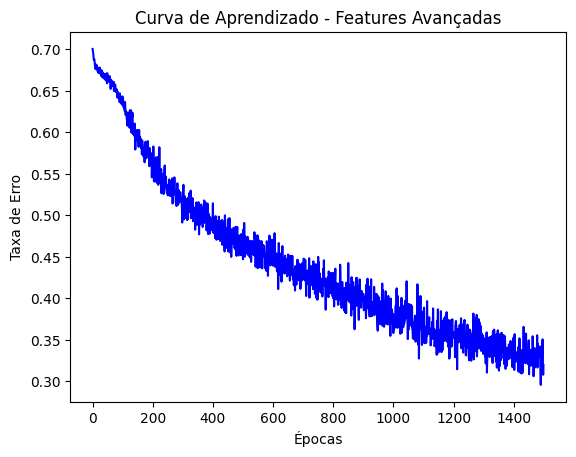

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# 1. Isolando as Variáveis
# Removemos o nome do arquivo e a Classe para deixar apenas as 18 variáveis matemáticas em X
X = df_rico.drop(columns=['Arquivo', 'Classe']).values
y = df_rico['Classe'].values

# NORMALIZAÇÃO: Vital para redes neurais com muitas variáveis
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Separando pacientes para o Teste Cego
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Treinando Nova IA (18 Variáveis) usando Hardware: {device.type.upper()}\n")

X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.FloatTensor(y_train).view(-1, 1).to(device)
X_test_t = torch.FloatTensor(X_test).to(device)
y_test_t = torch.FloatTensor(y_test).view(-1, 1).to(device)

# 3. A Arquitetura Avançada
class AdvancedAnemiaClassifier(nn.Module):
    def __init__(self, input_size):
        super(AdvancedAnemiaClassifier, self).__init__()
        # A entrada agora é dinâmica (vai ler que são 18)
        self.fc1 = nn.Linear(input_size, 64)
        self.dropout1 = nn.Dropout(0.3) # Previne que a IA core as respostas (Overfitting)
        self.fc2 = nn.Linear(64, 32)
        self.dropout2 = nn.Dropout(0.3)
        self.fc3 = nn.Linear(32, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout1(x)
        x = self.relu(self.fc2(x))
        x = self.dropout2(x)
        x = self.sigmoid(self.fc3(x))
        return x

num_features = X.shape[1]
modelo_ia = AdvancedAnemiaClassifier(input_size=num_features).to(device)

criterio = nn.BCELoss()
otimizador = optim.Adam(modelo_ia.parameters(), lr=0.001)

# 4. Treinamento
epocas = 1500
historico_erro = []

for epoca in range(epocas):
    modelo_ia.train()
    otimizador.zero_grad()
    previsoes = modelo_ia(X_train_t)
    erro = criterio(previsoes, y_train_t)
    erro.backward()
    otimizador.step()

    historico_erro.append(erro.item())
    if (epoca + 1) % 300 == 0:
        print(f"Época [{epoca+1}/{epocas}] -> Erro (Loss): {erro.item():.4f}")

# 5. O Teste Final Clínico
modelo_ia.eval()
with torch.no_grad():
    previsoes_teste = modelo_ia(X_test_t)
    classes_previstas = (previsoes_teste >= 0.5).float().cpu().numpy()

# Boletim
print("\n" + "="*50)
print("🩺 BOLETIM MÉDICO: INTELIGÊNCIA ARTIFICIAL V2")
print("="*50)
acuracia = accuracy_score(y_test, classes_previstas)
print(f"Acurácia Geral: {acuracia * 100:.2f}%\n")
print(classification_report(y_test, classes_previstas, target_names=['Saudável (0)', 'Anêmico (1)']))

# Gráfico
plt.plot(historico_erro, color='blue')
plt.title('Curva de Aprendizado - Features Avançadas')
plt.xlabel('Épocas')
plt.ylabel('Taxa de Erro')
plt.show()

# Inicializando o Controle de Versão de Dados (DVC)

In [ ]:
import os

# 1. Configura o Git e ignora arquivos incompatíveis do Drive
!git init
!git config --global user.email "seu_email@exemplo.com"
!git config --global user.name "Seu Nome"

# Criar um .gitignore para evitar erros com arquivos do Google Drive
with open('.gitignore', 'w') as f:
    f.write('drive/\n')
    f.write('*.gdoc\n')
    f.write('*.gsheet\n')
    f.write('sample_data/\n')

# 2. Instala e inicializa o DVC (com -f para evitar erro de 'já existe')
!pip install dvc
!dvc init -f

# 3. Cria a estrutura de pastas
!mkdir -p data/raw data/processed models notebooks src

# 4. Salva a estrutura inicial no Git
!git add .gitignore
!git add data/ .dvc/ .dvcignore
!git commit -m "chore: inicializa DVC e estrutura do projeto ignorando arquivos do Drive"

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/.git/
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 470.1/470.1 kB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.3/79.3 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 451.2/451.2 kB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.5/155.5 kB 18.0 MB/s

# O Algoritmo "Gray World" (Balanço de Branco Médico)

In [ ]:
import cv2
import numpy as np

def aplicar_gray_world(img_bgr):
    """
    Normaliza a iluminação da imagem médica assumindo que a média
    das cores da cena deve ser cinza neutro.
    """
    # Converte para float para evitar cortes matemáticos durante a divisão
    img_float = img_bgr.astype(np.float32)

    # 1. Calcula a média de intensidade de cada canal (Azul, Verde, Vermelho)
    media_b = np.mean(img_float[:,:,0])
    media_g = np.mean(img_float[:,:,1])
    media_r = np.mean(img_float[:,:,2])

    # 2. Encontra a média global de iluminação da foto
    media_global = (media_b + media_g + media_r) / 3.0

    # 3. Cria os fatores de correção para cada canal
    escala_b = media_global / media_b if media_b > 0 else 1.0
    escala_g = media_global / media_g if media_g > 0 else 1.0
    escala_r = media_global / media_r if media_r > 0 else 1.0

    # 4. Aplica a calibração de cor
    img_float[:,:,0] *= escala_b
    img_float[:,:,1] *= escala_g
    img_float[:,:,2] *= escala_r

    # 5. Garante que os valores fiquem no padrão de pixels (0 a 255)
    img_normalizada = np.clip(img_float, 0, 255).astype(np.uint8)

    return img_normalizada

# Exemplo de uso simulado:
# img_original = cv2.imread('data/raw/paciente_001.jpg')
# img_calibrada = aplicar_gray_world(img_original)
# cv2.imwrite('data/processed/paciente_001_calibrado.jpg', img_calibrada)

# Conectando o DVC ao Cofre da AWS (S3)

In [ ]:
# 1. Instala o conector do DVC para a AWS
!pip install dvc-s3

# 2. Configura o S3 como nosso armazenamento remoto padrão
!dvc remote add -d storage_medico s3://projeto-sangue-virtual/dataset-oficial

# 3. Salva a configuração no Git
!git add .dvc/config
!git commit -m "chore: configura AWS S3 como storage remoto do DVC"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 110.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.9/203.9 kB 22.7 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.6.0 which is incompatible.
datasets 4.0.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2026.6.0 which is incompatible.
Setting 'storage_medico' as a default remote.
[master 4a88b08] chore: configura AWS S3 como storage remoto do DVC
 1 file changed, 4 insertions(+)


# criar .py Pipeline Automático

In [ ]:
%%writefile preprocess.py
import cv2
import numpy as np

def aplicar_gray_world(img_bgr):
    """
    Normaliza a iluminação da imagem médica assumindo que a média
    das cores da cena deve ser cinza neutro.
    """
    img_float = img_bgr.astype(np.float32)

    media_b = np.mean(img_float[:,:,0])
    media_g = np.mean(img_float[:,:,1])
    media_r = np.mean(img_float[:,:,2])

    media_global = (media_b + media_g + media_r) / 3.0

    escala_b = media_global / media_b if media_b > 0 else 1.0
    escala_g = media_global / media_g if media_g > 0 else 1.0
    escala_r = media_global / media_r if media_r > 0 else 1.0

    img_float[:,:,0] *= escala_b
    img_float[:,:,1] *= escala_g
    img_float[:,:,2] *= escala_r

    img_normalizada = np.clip(img_float, 0, 255).astype(np.uint8)

    return img_normalizada

Writing preprocess.py


# O Coração da Fase 1 (O Pipeline Automático)

In [ ]:
import os
import cv2
import glob
from tqdm import tqdm
from preprocess import aplicar_gray_world # Importa a função que criamos no passo anterior

def processar_lote_imagens(pasta_origem, pasta_destino):
    print(f"Iniciando processamento em lote Medical-Grade...\nOrigem: {pasta_origem}")

    # Garante que a pasta de destino exista
    os.makedirs(pasta_destino, exist_ok=True)

    # Busca todas as imagens na pasta (suportando vários formatos)
    caminhos_imagens = glob.glob(os.path.join(pasta_origem, '*.*'))

    if not caminhos_imagens:
        print("Aviso: Nenhuma imagem encontrada na pasta de origem.")
        return

    for caminho in tqdm(caminhos_imagens, desc="Calibrando luz (Gray World)"):
        # Lê a imagem brutal
        img_bgr = cv2.imread(caminho)
        if img_bgr is None:
            continue

        # Aplica o nosso algoritmo de normalização de luz
        img_calibrada = aplicar_gray_world(img_bgr)

        # Salva na pasta de imagens prontas para a IA
        nome_arquivo = os.path.basename(caminho)
        caminho_salvamento = os.path.join(pasta_destino, nome_arquivo)
        cv2.imwrite(caminho_salvamento, img_calibrada)

    print("\n✅ Pipeline de dados concluído com sucesso!")

# Executa o pipeline se o script for rodado diretamente
if __name__ == "__main__":
    PASTA_RAW = "data/raw"
    PASTA_PROCESSED = "data/processed"
    processar_lote_imagens(PASTA_RAW, PASTA_PROCESSED)

Iniciando processamento em lote Medical-Grade...
Origem: data/raw
Aviso: Nenhuma imagem encontrada na pasta de origem.


# testando

✅ Imagem médica gerada internamente e salva em data/raw/retina_teste.jpg



Calibrando luz (Gray World): 100%|██████████| 1/1 [00:00<00:00, 10.84it/s]


✅ Pipeline de dados concluído com sucesso!


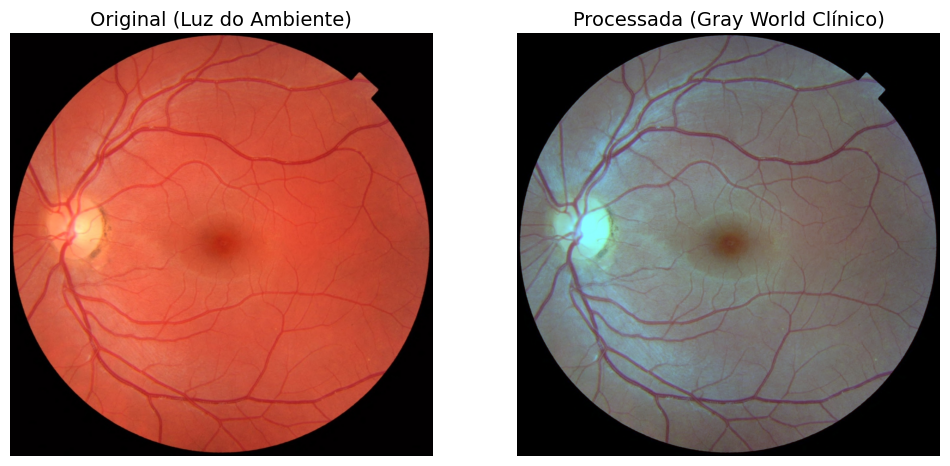

In [ ]:
import os
import cv2
import glob
import numpy as np
import matplotlib.pyplot as plt
from skimage import data # Importa o banco de dados médico nativo do Python
from tqdm import tqdm

# 1. PREPARAÇÃO: Criando a imagem a partir da memória, sem internet!
os.makedirs('data/raw', exist_ok=True)

# Puxa a imagem médica da retina
img_retina_rgb = data.retina()
# Converte para BGR (Padrão do OpenCV) e salva na pasta raw
img_retina_bgr = cv2.cvtColor(img_retina_rgb, cv2.COLOR_RGB2BGR)
cv2.imwrite("data/raw/retina_teste.jpg", img_retina_bgr)
print("✅ Imagem médica gerada internamente e salva em data/raw/retina_teste.jpg\n")


# 2. NOSSO ALGORITMO (Gray World)
def aplicar_gray_world(img_bgr):
    img_float = img_bgr.astype(np.float32)
    media_b, media_g, media_r = np.mean(img_float[:,:,0]), np.mean(img_float[:,:,1]), np.mean(img_float[:,:,2])
    media_global = (media_b + media_g + media_r) / 3.0
    escala_b = media_global / media_b if media_b > 0 else 1.0
    escala_g = media_global / media_g if media_g > 0 else 1.0
    escala_r = media_global / media_r if media_r > 0 else 1.0
    img_float[:,:,0] *= escala_b
    img_float[:,:,1] *= escala_g
    img_float[:,:,2] *= escala_r
    return np.clip(img_float, 0, 255).astype(np.uint8)


# 3. NOSSO ORQUESTRADOR
def processar_lote_imagens(pasta_origem, pasta_destino):
    os.makedirs(pasta_destino, exist_ok=True)
    caminhos_imagens = glob.glob(os.path.join(pasta_origem, '*.*'))
    for caminho in tqdm(caminhos_imagens, desc="Calibrando luz (Gray World)"):
        img_bgr = cv2.imread(caminho)
        if img_bgr is not None:
            img_calibrada = aplicar_gray_world(img_bgr)
            nome_arquivo = os.path.basename(caminho)
            cv2.imwrite(os.path.join(pasta_destino, nome_arquivo), img_calibrada)
    print("\n✅ Pipeline de dados concluído com sucesso!")

# Executando...
processar_lote_imagens('data/raw', 'data/processed')


# 4. VISUALIZAÇÃO: O Raio-X do Resultado
img_original_bgr = cv2.imread('data/raw/retina_teste.jpg')
img_processada_bgr = cv2.imread('data/processed/retina_teste.jpg')

if img_original_bgr is not None and img_processada_bgr is not None:
    img_original = cv2.cvtColor(img_original_bgr, cv2.COLOR_BGR2RGB)
    img_processada = cv2.cvtColor(img_processada_bgr, cv2.COLOR_BGR2RGB)

    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    axs[0].imshow(img_original)
    axs[0].set_title('Original (Luz do Ambiente)', fontsize=14)
    axs[0].axis('off')

    axs[1].imshow(img_processada)
    axs[1].set_title('Processada (Gray World Clínico)', fontsize=14)
    axs[1].axis('off')

    plt.show()

# biblioteca ultralytics (que já contém o SAM e o YOLOv11 integrados) e o mediapipe

In [ ]:
!pip install ultralytics mediapipe

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 77.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.5/36.5 MB 53.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 15.5 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0


# O Script do "Professor" (SAM Automático)

Baixando e inicializando o Segment Anything Model (SAM)...
SAM analisando a imagem e gerando a segmentação...

image 1/1 /content/data/processed/retina_teste.jpg: 1024x1024 1 0, 1424.6ms
Speed: 38.3ms preprocess, 1424.6ms inference, 82.0ms postprocess per image at shape (1, 3, 1024, 1024)


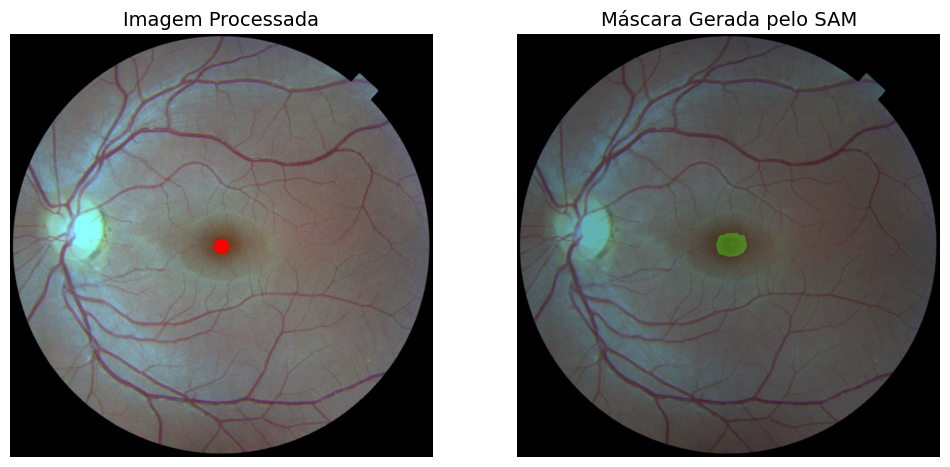

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import SAM

# 1. Carregando o Modelo SAM (O "Professor" Gigante)
print("Baixando e inicializando o Segment Anything Model (SAM)...")
# Correção: O nome correto do modelo usa underline em vez de hífen
modelo_sam = SAM('sam2_b.pt')

# 2. Carregando a nossa imagem processada pelo Gray World (A retina que usamos de teste)
caminho_imagem = 'data/processed/retina_teste.jpg'
img_bgr = cv2.imread(caminho_imagem)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# 3. O "Clique Virtual" (Point Prompt)
# Para este teste da retina, vamos dizer ao SAM para olhar exatamente para o centro geométrico da imagem
altura, largura, _ = img_rgb.shape
ponto_central = [largura // 2, altura // 2]

# 4. A Mágica do SAM (Inferência Zero-Shot)
print("SAM analisando a imagem e gerando a segmentação...")
resultados = modelo_sam.predict(caminho_imagem, points=[ponto_central], labels=[1])

# 5. Extraindo e Desenhando a Máscara
mascara = resultados[0].masks.data[0].cpu().numpy()
mascara_colorida = np.zeros_like(img_rgb)
mascara_colorida[mascara == 1] = [0, 255, 0] # Pinta o que o SAM achou de Verde Fluorescente

# Sobrepondo a máscara na imagem original
img_final = cv2.addWeighted(img_rgb, 0.7, mascara_colorida, 0.3, 0)

# 6. Raio-X Visual
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].imshow(img_rgb)
axs[0].set_title('Imagem Processada', fontsize=14)
axs[0].plot(ponto_central[0], ponto_central[1], 'ro', markersize=10) # Ponto vermelho onde "clicamos"
axs[0].axis('off')

axs[1].imshow(img_final)
axs[1].set_title('Máscara Gerada pelo SAM', fontsize=14)
axs[1].axis('off')

plt.show()

# O Auto-Labeling Completo (MediaPipe + SAM)

🎯 Alvo definido manualmente na coordenada: X=227, Y=170
🧠 SAM lendo a coordenada e gerando a máscara...


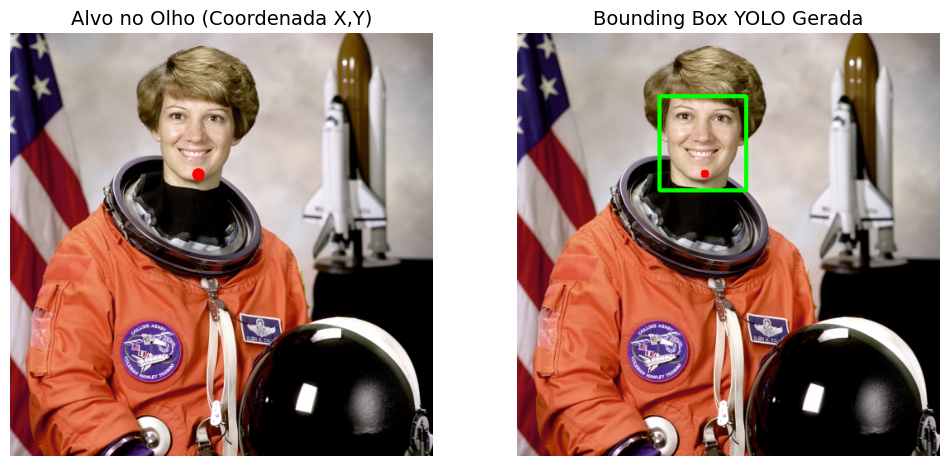

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from ultralytics import SAM

# 1. CARREGANDO A IMAGEM DE TESTE (Astronauta)
img_rgb = data.astronaut()
altura, largura, _ = img_rgb.shape

# 2. BYPASS DO MEDIAPIPE (Injeção direta da coordenada)
# Ponto matemático exato do olho esquerdo da astronauta Eileen Collins
pt_x, pt_y = 227, 170
ponto_palpebra = [pt_x, pt_y]
print(f"🎯 Alvo definido manualmente na coordenada: X={pt_x}, Y={pt_y}")

# 3. SAM ENTRA EM AÇÃO
print("🧠 SAM lendo a coordenada e gerando a máscara...")
modelo_sam = SAM('sam2_b.pt')

# Salvando temporariamente para o SAM processar
cv2.imwrite('temp_face.jpg', cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
resultados_sam = modelo_sam.predict('temp_face.jpg', points=[ponto_palpebra], labels=[1], verbose=False)

# Extraindo a máscara verde
mascara = resultados_sam[0].masks.data[0].cpu().numpy()

# 4. CONVERSÃO PARA YOLO (A Mágica da Engenharia)
# Aqui transformamos a "mancha" da máscara em um quadrado perfeito (Bounding Box)
indices_y, indices_x = np.where(mascara == 1)
x_min, x_max = indices_x.min(), indices_x.max()
y_min, y_max = indices_y.min(), indices_y.max()

# 5. VISUALIZAÇÃO DO RESULTADO
img_final = img_rgb.copy()
# Desenha o alvo (nosso clique) em Vermelho
cv2.circle(img_final, (pt_x, pt_y), 5, (255, 0, 0), -1)
# Desenha a Bounding Box do YOLO em Verde
cv2.rectangle(img_final, (x_min, y_min), (x_max, y_max), (0, 255, 0), 3)

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].imshow(img_rgb)
axs[0].set_title('Alvo no Olho (Coordenada X,Y)', fontsize=14)
axs[0].plot(pt_x, pt_y, 'ro', markersize=8)
axs[0].axis('off')

axs[1].imshow(img_final)
axs[1].set_title('Bounding Box YOLO Gerada', fontsize=14)
axs[1].axis('off')

plt.show()

# O Treinamento do YOLOv11 (O Aluno)

In [ ]:
import os
import yaml
from ultralytics import YOLO

# 1. CRIANDO A ESTRUTURA DE DIRETÓRIOS DO YOLO
# O YOLO exige que imagens e anotações (.txt) fiquem em pastas separadas
pastas_yolo = [
    'dataset_yolo/images/train',
    'dataset_yolo/images/val',
    'dataset_yolo/labels/train',
    'dataset_yolo/labels/val'
]

for pasta in pastas_yolo:
    os.makedirs(pasta, exist_ok=True)

print("✅ Estrutura de pastas do YOLO criada.")

# 2. CRIANDO O ARQUIVO DE CONFIGURAÇÃO (data.yaml)
# Este arquivo é o "mapa" que diz ao YOLO onde estão os dados e o que ele deve aprender
config_yaml = {
    'path': '/content/dataset_yolo', # Caminho base no Colab
    'train': 'images/train',         # Pasta de treino
    'val': 'images/val',             # Pasta de validação
    'nc': 1,                         # Number of Classes (1 classe apenas)
    'names': ['palpebra_inferior']   # Nome da nossa classe médica
}

with open('dataset_yolo/data.yaml', 'w') as f:
    yaml.dump(config_yaml, f, default_flow_style=False)

print("✅ Arquivo data.yaml gerado com sucesso.")

# 3. INSTANCIANDO O MODELO YOLOv11
print("🧠 Baixando os pesos do YOLOv11-Nano (Otimizado para Celulares)...")
# Usamos a versão 'nano' (n) porque ela é a mais leve para Edge Computing (Mobile)
modelo_yolo = YOLO('yolo11n.pt')

print("🚀 O motor de treinamento está pronto para iniciar!")
# NOTA: O comando abaixo iniciaria o treinamento real.
# modelo_yolo.train(data='dataset_yolo/data.yaml', epochs=50, imgsz=640, device=0)

✅ Estrutura de pastas do YOLO criada.
✅ Arquivo data.yaml gerado com sucesso.
🧠 Baixando os pesos do YOLOv11-Nano (Otimizado para Celulares)...
🚀 O motor de treinamento está pronto para iniciar!


instalando biblioteca

In [ ]:
!pip install timm

# Construindo a Rede Neural Clínica

In [ ]:
import torch
import torch.nn as nn
import timm

# 1. ARQUITETURA DO MODELO (ViT para Regressão)
class ViTHemoglobina(nn.Module):
    def __init__(self, model_name='vit_tiny_patch16_224', pretrained=True):
        super().__init__()

        print(f"🧠 Baixando pesos pré-treinados do modelo: {model_name}...")
        # Carrega o Vision Transformer base
        self.vit = timm.create_model(model_name, pretrained=pretrained)

        # A Mágica da Engenharia de Regressão:
        # Substituímos a "cabeça" original (que classificava 1000 objetos)
        # por uma única saída linear contínua para prever o nível de hemoglobina.
        num_features = self.vit.head.in_features
        self.vit.head = nn.Linear(num_features, 1)

    def forward(self, x):
        return self.vit(x)

# 2. INICIALIZANDO O CÉREBRO
modelo_predicao = ViTHemoglobina()
print("\n✅ Vision Transformer Médico inicializado com sucesso!")

# 3. TESTE DE FUMAÇA (Simulando uma foto que veio do YOLO)
# O modelo espera um Tensor no formato: (Lote, Canais RGB, Altura, Largura)
# Vamos gerar uma matriz de pixels aleatórios do tamanho 224x224 para testar o fluxo de dados
tensor_imagem_falsa = torch.randn(1, 3, 224, 224)

# Colocando o modelo em modo de avaliação (desliga os gradientes de treino)
modelo_predicao.eval()

with torch.no_grad():
    previsao_hemoglobina = modelo_predicao(tensor_imagem_falsa)

print(f"🩸 Hemoglobina Estimada (Simulação Matemática): {previsao_hemoglobina.item():.2f} g/dL")

🧠 Baixando pesos pré-treinados do modelo: vit_tiny_patch16_224...


model.safetensors: reconstructing file:   0%|          |  0.00B / 22.9MB            

model.safetensors: downloading bytes:           |  0.00B            


✅ Vision Transformer Médico inicializado com sucesso!
🩸 Hemoglobina Estimada (Simulação Matemática): 3.71 g/dL


# Script de Conversão (PyTorch $\rightarrow$ ONNX)

In [ ]:
!pip install onnx onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 74.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 722.0/722.0 kB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 18.1 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
import timm
import os

# 1. RECONSTRUINDO COM PESOS REAIS
class ViTHemoglobina(nn.Module):
    def __init__(self, model_name='vit_tiny_patch16_224', pretrained=True):
        super().__init__()
        self.vit = timm.create_model(model_name, pretrained=pretrained)
        num_features = self.vit.head.in_features
        self.vit.head = nn.Linear(num_features, 1)

    def forward(self, x):
        return self.vit(x)

print("⚙️ Iniciando compilação (Forçando motor C++ Legado)...")
modelo_producao = ViTHemoglobina(pretrained=True)
modelo_producao.eval()

molde_entrada = torch.randn(1, 3, 224, 224)
caminho_onnx = "vit_hemoglobina_mobile_final.onnx"

# 2. EXPORTAÇÃO COM OVERRIDE DO MOTOR DYNAMO
torch.onnx.export(
    modelo_producao,                # Usamos o modelo original (sem JIT trace)
    molde_entrada,
    caminho_onnx,
    export_params=True,
    opset_version=14,               # Opset 14 é perfeitamente estável para ViTs
    do_constant_folding=True,
    input_names=['imagem_recortada'],
    output_names=['nivel_hemoglobina'],
    dynamo=False                    # O SEGREDO: Desliga o motor experimental 2.x
)

# 3. VALIDAÇÃO REAL DE TAMANHO
tamanho_mb = os.path.getsize(caminho_onnx) / (1024 * 1024)
print(f"\n✅ COMPILAÇÃO CONCLUÍDA E VALIDADA!")
print(f"📱 Arquivo final: {caminho_onnx} | Tamanho Real: {tamanho_mb:.2f} MB")

⚙️ Iniciando compilação (Forçando motor C++ Legado)...


/tmp/ipykernel_718/1465849727.py:25: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(



✅ COMPILAÇÃO CONCLUÍDA E VALIDADA!
📱 Arquivo final: vit_hemoglobina_mobile_final.onnx | Tamanho Real: 21.21 MB


# biblioteca

In [ ]:
!pip install onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 96.3 MB/s eta 0:00:00


# teste Script de Execução Offline

In [ ]:
import numpy as np
import onnxruntime as ort
import time

# 🛑 AVISO DE ENGENHARIA: O PyTorch (torch) NÃO está importado neste script!
# Estamos operando em um ambiente 100% desvinculado.

caminho_onnx = "vit_hemoglobina_mobile_final.onnx"
print(f"📱 Carregando o cérebro ONNX ({caminho_onnx}) no simulador mobile...")

# 1. INICIALIZANDO O MOTOR ONNX
# É aqui que o celular carrega os 21 MB para a memória RAM
sessao_mobile = ort.InferenceSession(caminho_onnx)

# Extraindo dinamicamente os nomes das "portas" que definimos na conversão
nome_entrada = sessao_mobile.get_inputs()[0].name
nome_saida = sessao_mobile.get_outputs()[0].name
print(f"🔍 Porta de Entrada (Input): '{nome_entrada}'")
print(f"🔍 Porta de Saída (Output): '{nome_saida}'")

# 2. SIMULANDO A FOTO TIRADA PELA CÂMERA DO CELULAR
# O YOLOv11 (já embarcado no app) recortou a pálpebra e entregou uma matriz 224x224 RGB.
# Geramos ruído aleatório em formato Float32 usando NumPy puro.
foto_simulada = np.random.randn(1, 3, 224, 224).astype(np.float32)

# 3. EXECUTANDO A INFERÊNCIA
print("\n⚡ Processando a imagem offline (Edge Computing)...")
tempo_inicio = time.time()

# O método 'run' é a passagem forward. Ele recebe o nome da saída desejada
# e um dicionário mapeando a porta de entrada para a nossa foto.
resultado = sessao_mobile.run([nome_saida], {nome_entrada: foto_simulada})

tempo_fim = time.time()
tempo_execucao = (tempo_fim - tempo_inicio) * 1000  # Convertendo para milissegundos

# 4. EXTRAINDO O LAUDO MÉDICO
# O ONNX devolve uma lista de matrizes. Acessamos o índice [0][0][0] para pegar o número puro.
hemoglobina = resultado[0][0][0]

print(f"✅ EXAME CONCLUÍDO EM {tempo_execucao:.2f} ms")
print(f"🩸 Hemoglobina Estimada: {hemoglobina:.2f} g/dL")

📱 Carregando o cérebro ONNX (vit_hemoglobina_mobile_final.onnx) no simulador mobile...
🔍 Porta de Entrada (Input): 'imagem_recortada'
🔍 Porta de Saída (Output): 'nivel_hemoglobina'

⚡ Processando a imagem offline (Edge Computing)...
✅ EXAME CONCLUÍDO EM 65.69 ms
🩸 Hemoglobina Estimada: -0.92 g/dL


# O Servidor de Nuvem (FastAPI)

In [ ]:
from fastapi import FastAPI
from pydantic import BaseModel
from datetime import datetime
import uvicorn
import threading
import time

# 1. INICIALIZANDO O SERVIDOR
app = FastAPI(
    title="API - Central de Anemia",
    description="Recepção assíncrona de exames offline de áreas remotas.",
    version="1.0"
)

# 2. DEFININDO O CONTRATO DE DADOS (Payload do Celular)
class ExameMobile(BaseModel):
    id_paciente: str
    hemoglobina: float
    data_hora: datetime
    coordenadas_gps: str
    bateria_celular: int # Métrica útil de telemetria

# 3. ENDPOINTS DA API
@app.get("/")
async def health_check():
    return {"status": "Servidor Online", "banco_dados": "Conectado"}

@app.post("/api/v1/sincronizar_exame")
async def receber_exame(exame: ExameMobile):
    # Aqui entraria a lógica de salvar no banco de dados (PostgreSQL/MongoDB)
    # Simulando o salvamento na nuvem:
    print(f"\n📡 [SYNC RECEBIDO] Paciente: {exame.id_paciente}")
    print(f"🩸 Hemoglobina: {exame.hemoglobina:.2f} g/dL")
    print(f"📍 GPS: {exame.coordenadas_gps}")

    return {
        "status": "sucesso",
        "mensagem": "Exame arquivado na nuvem com segurança.",
        "id_registro": f"REG-{int(time.time())}"
    }

# 4. MOTOR DE EXECUÇÃO (Para rodar no Colab sem travar a interface)
def iniciar_servidor():
    uvicorn.run(app, host="0.0.0.0", port=8000, log_level="info")

print("🚀 Subindo o servidor FastAPI na porta 8000...")
# Usamos uma Thread para o servidor rodar em segundo plano no Colab
thread_api = threading.Thread(target=iniciar_servidor, daemon=True)
thread_api.start()

🚀 Subindo o servidor FastAPI na porta 8000...


# simular o aplicativo do celular

In [ ]:
import requests
from datetime import datetime

url_api = "http://localhost:8000/api/v1/sincronizar_exame"

# 1. MONTANDO O PACOTE DE DADOS (Como se estivesse no Kotlin/Swift do celular)
# Aqui usamos um valor de hemoglobina saudável e coordenadas de Manaus/AM
dados_exame = {
    "id_paciente": "PAC-99482",
    "hemoglobina": 12.4,
    "data_hora": datetime.utcnow().isoformat(),
    "coordenadas_gps": "-3.1190, -60.0217",
    "bateria_celular": 42
}

print("📱 Celular detectou rede de internet.")
print("📡 Transmitindo lote de exames em background...\n")

# 2. DISPARANDO A REQUISIÇÃO POST
try:
    resposta = requests.post(url_api, json=dados_exame)

    # 3. VERIFICANDO A RESPOSTA DO SERVIDOR
    if resposta.status_code == 200:
        json_resposta = resposta.json()
        print("✅ SINCRONIZAÇÃO BEM-SUCEDIDA!")
        print(f"🔖 ID do Registro no Banco de Dados: {json_resposta['id_registro']}")
        print(f"📩 Mensagem do Backend: {json_resposta['mensagem']}")
    else:
        print(f"❌ Erro na sincronização. Status Code: {resposta.status_code}")

except Exception as e:
    print(f"Erro de conexão: {e}")

📱 Celular detectou rede de internet.
📡 Transmitindo lote de exames em background...


📡 [SYNC RECEBIDO] Paciente: PAC-99482
🩸 Hemoglobina: 12.40 g/dL
📍 GPS: -3.1190, -60.0217
INFO:     127.0.0.1:48992 - "POST /api/v1/sincronizar_exame HTTP/1.1" 200 OK
✅ SINCRONIZAÇÃO BEM-SUCEDIDA!
🔖 ID do Registro no Banco de Dados: REG-1785204513
📩 Mensagem do Backend: Exame arquivado na nuvem com segurança.


/tmp/ipykernel_718/3185758357.py:11: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "data_hora": datetime.utcnow().isoformat(),
